# Predict RF location (x, y) from response matrix — simple MLP

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

N = 9  # 9x9 grid

# --- Bin on the full dataset so train/test share one fixed grid ---
x_edges = np.linspace(Y[:, 0].min(), Y[:, 0].max(), N + 1)
y_edges = np.linspace(Y[:, 1].min(), Y[:, 1].max(), N + 1)
bx = np.clip(np.digitize(Y[:, 0], x_edges[1:-1]), 0, N - 1)
by = np.clip(np.digitize(Y[:, 1], y_edges[1:-1]), 0, N - 1)
labels = by * N + bx                       # single class 0..80

# --- Stratified split: carries X, continuous Y, and bin labels together ---
X_train, X_test, Y_train, Y_test, lbl_train, lbl_test = train_test_split(
    X, Y, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# --- Regularized classifier ---
clf = MLPClassifier(
    hidden_layer_sizes=(64,),
    alpha=1.0,                 # strong L2
    early_stopping=True,
    n_iter_no_change=15,
    max_iter=1000,
    random_state=42,
)
clf.fit(X_train, lbl_train)

pred = clf.predict(X_test)
px, py = pred % N, pred // N               # decode predicted grid coords
tx, ty = lbl_test % N, lbl_test // N       # decode true grid coords



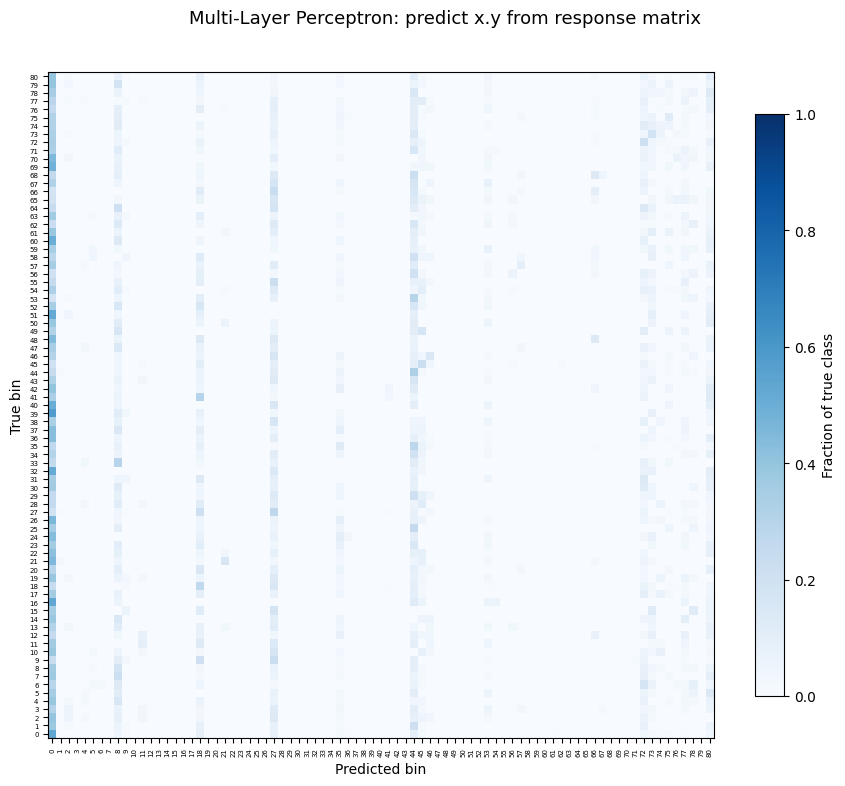

In [27]:
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score

bin_labels = list(range(N * N))  # 0..80

fig, ax = plt.subplots(figsize=(9, 8))

cm = confusion_matrix(lbl_test, pred, labels=bin_labels, normalize='true')
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1, origin='lower')
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, fontsize=5, rotation=90)
ax.set_yticks(range(len(bin_labels)))
ax.set_yticklabels(bin_labels, fontsize=5)
ax.set_xlabel("Predicted bin")
ax.set_ylabel("True bin")

acc     = accuracy_score(lbl_test, pred)
bal_acc = balanced_accuracy_score(lbl_test, pred)

plt.colorbar(im, ax=ax, label="Fraction of true class", shrink=0.8)

fig.suptitle("Multi-Layer Perceptron: predict x.y from response matrix", fontsize=13)
fig.tight_layout()
plt.show()

## Predict cluster from flattened RF map

In [4]:
from sklearn.neural_network import MLPClassifier

# Load cluster assignments
cluster_df = pd.read_csv(RESULTS_DIR / "ephys_cluster_assignments.csv")

# Merge cluster labels with rf path
df = cluster_df.merge(rf_df[['unit_id', 'rf_map_path']], on='unit_id', how='inner')
df = df.dropna(subset=['rf_map_path'])
print(f"Units with RF map: {len(df)}")

# Load flattened RF maps
rf_maps = []
valid_rows = []
for _, row in df.iterrows():
    try:
        data = np.load(row['rf_map_path'])
        rf_maps.append(data['rf'].ravel())
        valid_rows.append(row)
    except Exception:
        pass

X_rf_flat = np.array(rf_maps, dtype=np.float32)
valid_df   = pd.DataFrame(valid_rows).reset_index(drop=True)
y_cluster  = valid_df['cluster'].values

print(f"X shape (flattened RF maps): {X_rf_flat.shape}")
print(f"y shape (cluster labels):    {y_cluster.shape}")

# Train/test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_rf_flat, y_cluster, test_size=0.2, random_state=42, stratify=y_cluster
)

scaler_c  = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c  = scaler_c.transform(X_test_c)

# Fit classifier — increase max_iter and use early stopping to let it converge
clf = MLPClassifier(
    hidden_layer_sizes=(256, 256),
    max_iter=1000,
    random_state=42,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)
clf.fit(X_train_c, y_train_c)

n_clusters = len(np.unique(y_cluster))
print(f"\nStopped at iteration: {clf.n_iter_}")
print(f"Accuracy on test set: {clf.score(X_test_c, y_test_c):.4f}")
print(f"Chance level:         {1/n_clusters:.4f}")

Units with RF map: 20374
X shape (flattened RF maps): (20374, 81)
y shape (cluster labels):    (20374,)
Iteration 1, loss = 2.22218299
Validation score: 0.307362
Iteration 2, loss = 2.03661704
Validation score: 0.346012
Iteration 3, loss = 1.96236134
Validation score: 0.366871
Iteration 4, loss = 1.90903127
Validation score: 0.361963
Iteration 5, loss = 1.86841881
Validation score: 0.393252
Iteration 6, loss = 1.82408738
Validation score: 0.385276
Iteration 7, loss = 1.80239403
Validation score: 0.408589
Iteration 8, loss = 1.76727378
Validation score: 0.399387
Iteration 9, loss = 1.75412965
Validation score: 0.420859
Iteration 10, loss = 1.73584425
Validation score: 0.419632
Iteration 11, loss = 1.70833266
Validation score: 0.412270
Iteration 12, loss = 1.70849288
Validation score: 0.428834
Iteration 13, loss = 1.68790221
Validation score: 0.430675
Iteration 14, loss = 1.67228377
Validation score: 0.437423
Iteration 15, loss = 1.66361797
Validation score: 0.408589
Iteration 16, loss =

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_c = clf.predict(X_test_c)
cluster_labels = sorted(np.unique(y_cluster))

cm = confusion_matrix(y_test_c, y_pred_c, labels=cluster_labels, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(cluster_labels)))
ax.set_xticklabels(cluster_labels)
ax.set_yticks(range(len(cluster_labels)))
ax.set_yticklabels(cluster_labels)
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("True cluster")
acc = clf.score(X_test_c, y_test_c)
ax.set_title(f"Confusion matrix (row-normalized)\nAccuracy={acc:.3f}  Chance={1/len(cluster_labels):.3f}")
plt.colorbar(im, ax=ax, label="Fraction of true class")
fig.tight_layout()
plt.show()

## What is the network paying attention to?

### 1. Average RF map per cluster
Reshape the 81 features back to 2D and show the mean RF for each cluster — what the model learned to separate.

RF map shape: 9 x 9


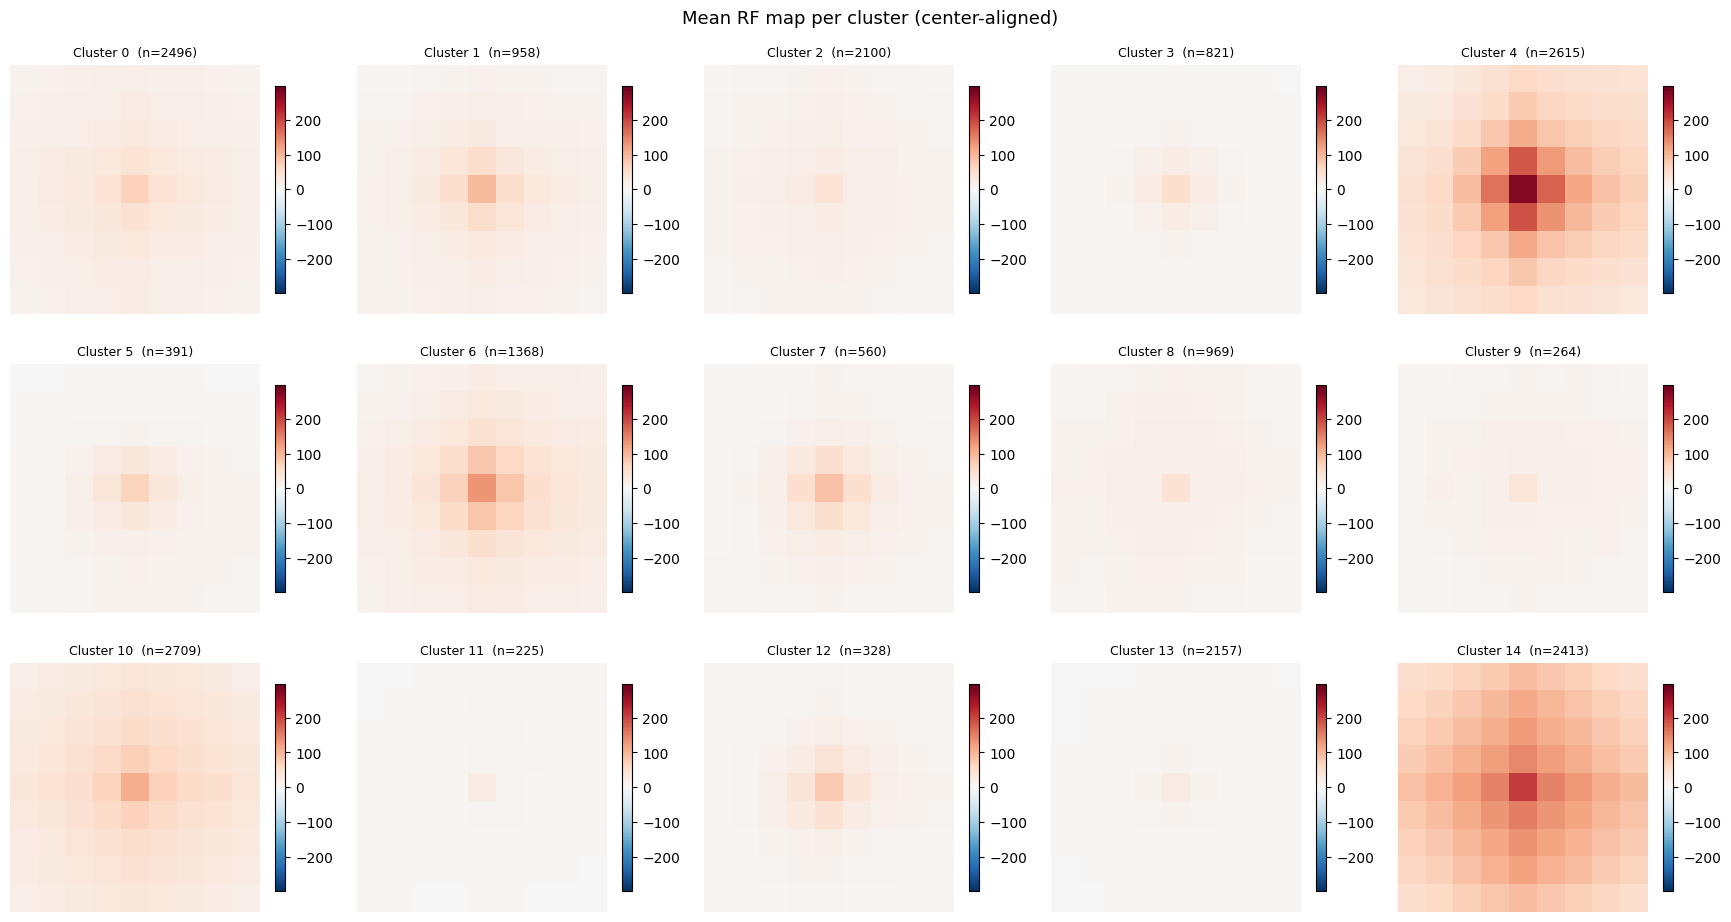

In [23]:
n_pixels = X_rf_flat.shape[1]
rf_side  = int(np.round(np.sqrt(n_pixels)))
print(f"RF map shape: {rf_side} x {rf_side}")

# Center-align each RF map by shifting its peak to the center before averaging
from scipy.ndimage import shift

def center_align_rf(rf_flat, rf_side):
    """Shift RF map so its peak is at the center pixel."""
    rf_2d   = rf_flat.reshape(rf_side, rf_side)
    peak    = np.unravel_index(np.argmax(rf_2d), rf_2d.shape)
    center  = (rf_side // 2, rf_side // 2)
    delta   = (center[0] - peak[0], center[1] - peak[1])
    return shift(rf_2d, shift=delta, mode='constant', cval=0.0)

# Center-align all RF maps
X_aligned = np.array([
    center_align_rf(rf, rf_side).ravel() for rf in X_rf_flat
], dtype=np.float32)

# Plot mean aligned RF per cluster
n_cols = 5
n_rows = int(np.ceil(len(cluster_labels) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.2 * n_rows))
axes = np.array(axes).ravel()

vabs = np.percentile(np.abs(X_aligned), 98)

for i, cl in enumerate(cluster_labels):
    mask    = y_cluster == cl
    mean_rf = X_aligned[mask].mean(axis=0).reshape(rf_side, rf_side)
    ax = axes[i]
    im = ax.imshow(mean_rf, cmap='RdBu_r', vmin=-vabs, vmax=vabs, origin='lower')
    ax.set_title(f"Cluster {cl}  (n={mask.sum()})", fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=0.7)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle("Mean RF map per cluster (center-aligned)", fontsize=13)
fig.tight_layout()
plt.show()

### 2. Permutation importance per pixel
Shuffle one pixel at a time across the test set and measure the drop in accuracy. High drop = that spatial location is what the network relies on.

Computing permutation importance (this may take a minute)...


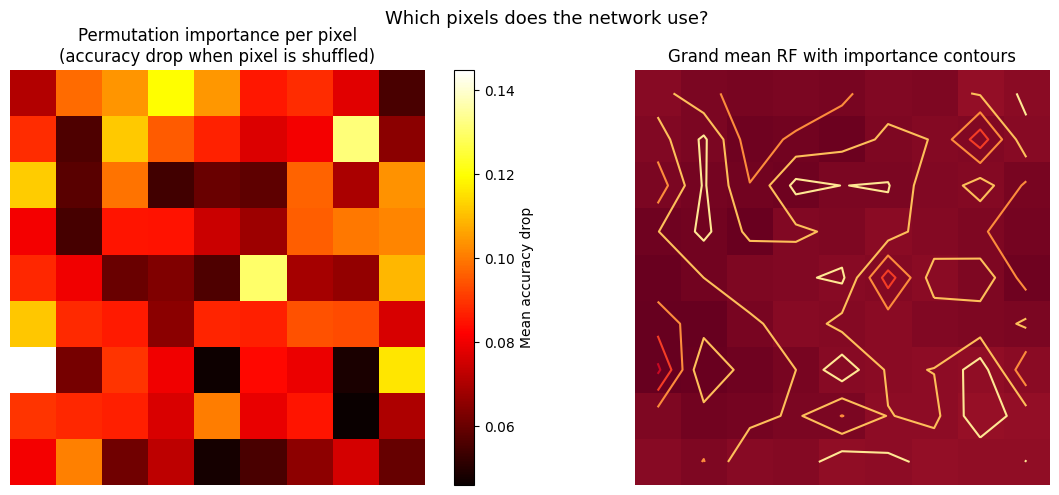


Top 10 most important pixels (flat index → row, col):
  pixel  18 (row=2, col=0)  importance=0.1448 ± 0.0039
  pixel  70 (row=7, col=7)  importance=0.1317 ± 0.0039
  pixel  41 (row=4, col=5)  importance=0.1298 ± 0.0028
  pixel  75 (row=8, col=3)  importance=0.1196 ± 0.0031
  pixel  26 (row=2, col=8)  importance=0.1160 ± 0.0045
  pixel  54 (row=6, col=0)  importance=0.1122 ± 0.0043
  pixel  65 (row=7, col=2)  importance=0.1117 ± 0.0049
  pixel  27 (row=3, col=0)  importance=0.1112 ± 0.0025
  pixel  44 (row=4, col=8)  importance=0.1091 ± 0.0042
  pixel  76 (row=8, col=4)  importance=0.1046 ± 0.0025


In [24]:
from sklearn.inspection import permutation_importance

print("Computing permutation importance (this may take a minute)...")
result = permutation_importance(
    clf, X_test_c, y_test_c,
    n_repeats=10,
    random_state=42,
    n_jobs=1,   # n_jobs=-1 causes subprocess pickle errors in this environment
)

# Reshape importance scores back to RF map dimensions
importance_map = result.importances_mean.reshape(rf_side, rf_side)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Importance map
im = axes[0].imshow(importance_map, cmap='hot', origin='lower')
axes[0].set_title("Permutation importance per pixel\n(accuracy drop when pixel is shuffled)")
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], label="Mean accuracy drop")

# Overlay importance contour on the grand mean RF
grand_mean_rf = X_rf_flat.mean(axis=0).reshape(rf_side, rf_side)
axes[1].imshow(grand_mean_rf, cmap='RdBu_r', origin='lower',
               vmin=-np.percentile(np.abs(grand_mean_rf), 98),
               vmax= np.percentile(np.abs(grand_mean_rf), 98))
axes[1].contour(importance_map, levels=5, cmap='YlOrRd', linewidths=1.5)
axes[1].set_title("Grand mean RF with importance contours")
axes[1].axis('off')

fig.suptitle("Which pixels does the network use?", fontsize=13)
fig.tight_layout()
plt.show()

# Print top pixels
top_pixels = np.argsort(result.importances_mean)[::-1][:10]
print("\nTop 10 most important pixels (flat index → row, col):")
for p in top_pixels:
    r, c = divmod(p, rf_side)
    print(f"  pixel {p:3d} (row={r}, col={c})  importance={result.importances_mean[p]:.4f} ± {result.importances_std[p]:.4f}")

## Retrain classifier on center-aligned RF maps
Does RF *shape* (not just position) predict cluster?

In [25]:
# Train/test split on aligned maps (same indices as before for fair comparison)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_aligned, y_cluster, test_size=0.2, random_state=42, stratify=y_cluster
)

scaler_a  = StandardScaler()
X_train_a = scaler_a.fit_transform(X_train_a)
X_test_a  = scaler_a.transform(X_test_a)

clf_aligned = MLPClassifier(
    hidden_layer_sizes=(256, 256),
    max_iter=1000,
    random_state=42,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)
clf_aligned.fit(X_train_a, y_train_a)

print(f"\nStopped at iteration: {clf_aligned.n_iter_}")
print(f"\nUnaligned RF accuracy: {clf.score(X_test_c, y_test_c):.4f}")
print(f"Aligned RF accuracy:   {clf_aligned.score(X_test_a, y_test_a):.4f}")
print(f"Chance level:          {1/n_clusters:.4f}")

Iteration 1, loss = 2.18778254
Validation score: 0.304294
Iteration 2, loss = 2.02568656
Validation score: 0.352147
Iteration 3, loss = 1.96646818
Validation score: 0.345399
Iteration 4, loss = 1.93814955
Validation score: 0.347853
Iteration 5, loss = 1.90782234
Validation score: 0.352147
Iteration 6, loss = 1.88236489
Validation score: 0.369939
Iteration 7, loss = 1.88125873
Validation score: 0.379755
Iteration 8, loss = 1.86191454
Validation score: 0.383436
Iteration 9, loss = 1.85055419
Validation score: 0.376687
Iteration 10, loss = 1.82964234
Validation score: 0.379755
Iteration 11, loss = 1.81758724
Validation score: 0.390184
Iteration 12, loss = 1.81605816
Validation score: 0.377301
Iteration 13, loss = 1.80563877
Validation score: 0.397546
Iteration 14, loss = 1.79307879
Validation score: 0.385890
Iteration 15, loss = 1.78345887
Validation score: 0.384049
Iteration 16, loss = 1.76900012
Validation score: 0.364417
Iteration 17, loss = 1.77118522
Validation score: 0.376687
Iterat

## Confusion matrix — aligned RF classifier

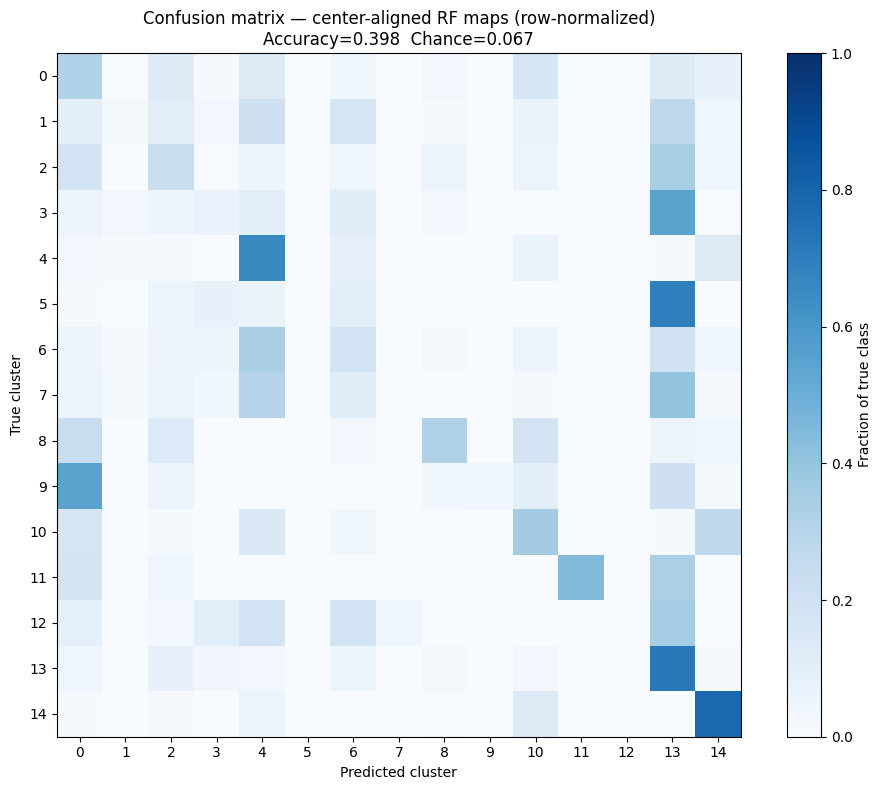

In [26]:
y_pred_a = clf_aligned.predict(X_test_a)

cm_a = confusion_matrix(y_test_a, y_pred_a, labels=cluster_labels, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_a, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(cluster_labels)))
ax.set_xticklabels(cluster_labels)
ax.set_yticks(range(len(cluster_labels)))
ax.set_yticklabels(cluster_labels)
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("True cluster")
acc_a = clf_aligned.score(X_test_a, y_test_a)
ax.set_title(f"Confusion matrix — center-aligned RF maps (row-normalized)\nAccuracy={acc_a:.3f}  Chance={1/n_clusters:.3f}")
plt.colorbar(im, ax=ax, label="Fraction of true class")
fig.tight_layout()
plt.show()

## Permutation importance — center-aligned RF maps
Now importance should reflect which parts of the RF *shape* matter (center vs surround), not just position.

Computing permutation importance on aligned RF maps (this may take a minute)...


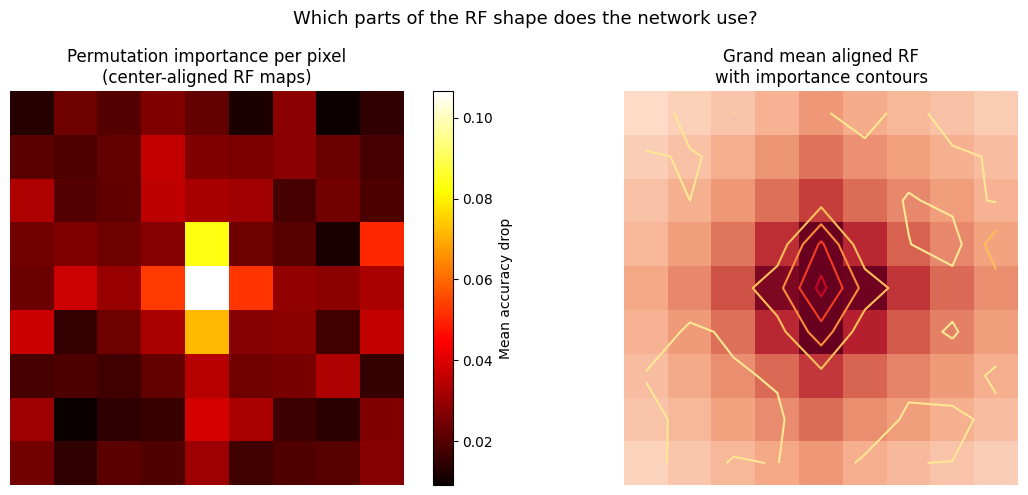

In [27]:
print("Computing permutation importance on aligned RF maps (this may take a minute)...")
result_a = permutation_importance(
    clf_aligned, X_test_a, y_test_a,
    n_repeats=10,
    random_state=42,
    n_jobs=1,
)

importance_map_a = result_a.importances_mean.reshape(rf_side, rf_side)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(importance_map_a, cmap='hot', origin='lower')
axes[0].set_title("Permutation importance per pixel\n(center-aligned RF maps)")
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], label="Mean accuracy drop")

# Overlay on grand mean aligned RF
grand_mean_aligned = X_aligned.mean(axis=0).reshape(rf_side, rf_side)
axes[1].imshow(grand_mean_aligned, cmap='RdBu_r', origin='lower',
               vmin=-np.percentile(np.abs(grand_mean_aligned), 98),
               vmax= np.percentile(np.abs(grand_mean_aligned), 98))
axes[1].contour(importance_map_a, levels=5, cmap='YlOrRd', linewidths=1.5)
axes[1].set_title("Grand mean aligned RF\nwith importance contours")
axes[1].axis('off')

fig.suptitle("Which parts of the RF shape does the network use?", fontsize=13)
fig.tight_layout()
plt.show()

## Amplitude vs shape: retrain with amplitude-normalized RF maps
Remove overall gain by normalizing each RF map to unit max. If accuracy drops a lot, amplitude was driving the result. If it stays high, the *shape* itself is predictive.

In [28]:
# Normalize each aligned RF map to its own max (removes amplitude, keeps shape)
max_vals = X_aligned.max(axis=1, keepdims=True)
max_vals = np.where(max_vals == 0, 1, max_vals)  # avoid divide-by-zero
X_shape_only = X_aligned / max_vals

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_shape_only, y_cluster, test_size=0.2, random_state=42, stratify=y_cluster
)

scaler_s  = StandardScaler()
X_train_s = scaler_s.fit_transform(X_train_s)
X_test_s  = scaler_s.transform(X_test_s)

clf_shape = MLPClassifier(
    hidden_layer_sizes=(256, 256),
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)
clf_shape.fit(X_train_s, y_train_s)

print(f"Unaligned (position+amplitude+shape): {clf.score(X_test_c, y_test_c):.4f}")
print(f"Aligned   (amplitude+shape):          {clf_aligned.score(X_test_a, y_test_a):.4f}")
print(f"Shape only (amplitude removed):       {clf_shape.score(X_test_s, y_test_s):.4f}")
print(f"Chance level:                         {1/n_clusters:.4f}")

Unaligned (position+amplitude+shape): 0.4611
Aligned   (amplitude+shape):          0.3978
Shape only (amplitude removed):       0.3936
Chance level:                         0.0667


## Confusion matrix — shape-only classifier

In [ ]:
y_pred_s = clf_shape.predict(X_test_s)

cm_s = confusion_matrix(y_test_s, y_pred_s, labels=cluster_labels, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_s, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(cluster_labels)))
ax.set_xticklabels(cluster_labels)
ax.set_yticks(range(len(cluster_labels)))
ax.set_yticklabels(cluster_labels)
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("True cluster")
acc_s = clf_shape.score(X_test_s, y_test_s)
ax.set_title(f"Confusion matrix — shape-only RF maps (row-normalized)\nAccuracy={acc_s:.3f}  Chance={1/n_clusters:.3f}")
plt.colorbar(im, ax=ax, label="Fraction of true class")
fig.tight_layout()
plt.show()

## Confusion matrix comparison — all three classifiers side by side

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(28, 8))

configs = [
    (cm,   clf.score(X_test_c, y_test_c),   "Unaligned\n(position + amplitude + shape)"),
    (cm_a, clf_aligned.score(X_test_a, y_test_a), "Center-aligned\n(amplitude + shape)"),
    (cm_s, clf_shape.score(X_test_s, y_test_s),   "Shape-only\n(amplitude removed)"),
]

for ax, (mat, acc, title) in zip(axes, configs):
    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(cluster_labels)))
    ax.set_xticklabels(cluster_labels)
    ax.set_yticks(range(len(cluster_labels)))
    ax.set_yticklabels(cluster_labels)
    ax.set_xlabel("Predicted cluster")
    ax.set_ylabel("True cluster")
    ax.set_title(f"{title}\nAcc={acc:.3f}  Chance={1/n_clusters:.3f}")
    plt.colorbar(im, ax=ax, label="Fraction of true class", shrink=0.8)

fig.suptitle("Confusion matrices — what drives cluster separability?", fontsize=14)
fig.tight_layout()
plt.show()

## Per-class metrics — classification report (best model: unaligned)

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Per-class precision, recall, F1 for all three models
for label, y_true, y_pred in [
    ("Unaligned",     y_test_c, y_pred_c),
    ("Center-aligned", y_test_a, y_pred_a),
    ("Shape-only",    y_test_s, y_pred_s),
]:
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, labels=cluster_labels,
                                target_names=[f"Cluster {c}" for c in cluster_labels]))

# Bar chart of per-cluster recall for the unaligned (best) model
per_class_recall = cm.diagonal()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(cluster_labels)), per_class_recall, color='steelblue', edgecolor='k', linewidth=0.5)
ax.axhline(1 / n_clusters, color='red', linestyle='--', label=f"Chance ({1/n_clusters:.2f})")
ax.set_xticks(range(len(cluster_labels)))
ax.set_xticklabels([f"C{c}" for c in cluster_labels])
ax.set_xlabel("Cluster")
ax.set_ylabel("Recall (true positive rate)")
ax.set_title("Per-cluster recall — unaligned RF classifier (best model)")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
plt.show()